# Physics-Informed Neural Networks for Activity Coefficient Prediction

This notebook presents the development of a physics-informed neural network (PINN) to predict activity coefficients using processed experimental data. By embedding thermodynamic constraints directly into the loss function, we incorporate domain knowledge into the model, ensuring thermodynamic consistency while leveraging a data-driven approach.

## Dependencies

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from pathlib import Path
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import MinMaxScaler
from torchmetrics.regression import R2Score

## PINN modeling

### Designing the Neural Network Components

Define the architecture of the neural network

In [32]:
torch.manual_seed(42)


class NeuralNetArchitecture(nn.Module):
    def __init__(self, in_dim: int, out_dim: int) -> None:
        super().__init__()
        self.layer_1 = nn.Linear(in_dim, 64)
        self.layer_2 = nn.Linear(64, 32)
        self.layer_3 = nn.Linear(32, 16)
        self.layer_4 = nn.Linear(16, out_dim)

    def forward(self, x):
        x = F.relu(self.layer_1(x))
        x = F.relu(self.layer_2(x))
        x = F.relu(self.layer_3(x))
        x = self.layer_4(x)

        return x

Implement a custom loss function that enforces thermodynamic consistency by embedding the Gibbs-Duhem equation into the standard MSE loss

In [ ]:
def gibbs_duhem_loss(
    y_pred: torch.Tensor, y_true: torch.Tensor, X: torch.Tensor, lambda_gd: float = 1.0
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    # MSE loss
    mse_loss = F.mse_loss(y_pred, y_true, reduction="mean")

    # Calculate ln(gamma)
    ln_gamma1 = y_pred[:, 0]
    ln_gamma2 = y_pred[:, 1]

    # Compute partial derivatives
    dgamma1_dx1 = torch.autograd.grad(
        ln_gamma1,
        X,
        grad_outputs=torch.ones_like(ln_gamma1),
        create_graph=True,
        allow_unused=True,
    )[0][:, 2]

    dgamma2_dx1 = torch.autograd.grad(
        ln_gamma2,
        X,
        grad_outputs=torch.ones_like(ln_gamma2),
        create_graph=True,
        allow_unused=True,
    )[0][:, 2]

    # Compute Gibbs-Duhem term
    x1 = X[:, 2]
    x2 = X[:, 5]

    gibbs_duhem_term = x1 * dgamma1_dx1 + x2 * dgamma2_dx1

    # Scale physics loss
    gd_loss = torch.mean(gibbs_duhem_term**2)

    # Total loss
    loss = mse_loss + lambda_gd * gd_loss

    return loss, mse_loss, gd_loss, gibbs_duhem_term

### Reading the data

Defining the data path conveniently:

In [34]:
DATA_PATH = Path("../data")

Reading the data into a `pandas.DataFrame`:

In [35]:
data = pd.read_csv(DATA_PATH / "processed" / "toy_problem_input_dataset.csv")

data

,r_1,q_1,x_1,r_2,q_2,x_2,T,gamma_1,gamma_2
0,9.5482,7.976,0.00,5.8486,4.936,1.00,398.839,0.102990,0.000000
1,9.5482,7.976,0.01,5.8486,4.936,0.99,399.213,0.098514,0.000020
2,9.5482,7.976,0.02,5.8486,4.936,0.98,399.590,0.094219,0.000080
3,9.5482,7.976,0.03,5.8486,4.936,0.97,399.971,0.090097,0.000180
4,9.5482,7.976,0.04,5.8486,4.936,0.96,400.355,0.086132,0.000320
...,...,...,...,...,...,...,...,...,...
4035,13.5946,11.216,0.96,3.9243,3.668,0.04,509.434,0.000370,0.496548
4036,13.5946,11.216,0.97,3.9243,3.668,0.03,532.267,0.000180,0.453976
4037,13.5946,11.216,0.98,3.9243,3.668,0.02,568.855,0.000060,0.389959
4038,13.5946,11.216,0.99,3.9243,3.668,0.01,600.617,0.000010,0.340720


Remove rows with NaN values:

In [36]:
data.dropna(inplace=True)
data.reset_index(drop=True, inplace=True)

data

,r_1,q_1,x_1,r_2,q_2,x_2,T,gamma_1,gamma_2
0,9.5482,7.976,0.00,5.8486,4.936,1.00,398.839,0.102990,0.000000
1,9.5482,7.976,0.01,5.8486,4.936,0.99,399.213,0.098514,0.000020
2,9.5482,7.976,0.02,5.8486,4.936,0.98,399.590,0.094219,0.000080
3,9.5482,7.976,0.03,5.8486,4.936,0.97,399.971,0.090097,0.000180
4,9.5482,7.976,0.04,5.8486,4.936,0.96,400.355,0.086132,0.000320
...,...,...,...,...,...,...,...,...,...
4031,13.5946,11.216,0.96,3.9243,3.668,0.04,509.434,0.000370,0.496548
4032,13.5946,11.216,0.97,3.9243,3.668,0.03,532.267,0.000180,0.453976
4033,13.5946,11.216,0.98,3.9243,3.668,0.02,568.855,0.000060,0.389959
4034,13.5946,11.216,0.99,3.9243,3.668,0.01,600.617,0.000010,0.340720


### PINN training

Defining the device and splitting the data into training and test sets

In [37]:
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

features = data.iloc[:, :-2].values
labels = data.iloc[:, -2:].values

X, X_test, y, y_test = train_test_split(
    features, labels, test_size=0.1, random_state=42
)

Defining the cross-validation setup

In [38]:
k_folds = 10
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

Specifying training hyperparameters

In [39]:
num_epochs = 10000
learning_rate = 5e-3
lambda_gd = 1
patience = 1000

Executing the cross-validation training loop to evaluate the best selection of hyperparameters

In [ ]:
# Combined loss lists
fold_losses = []
val_losses = []
test_losses = []

# For plotting per fold
train_mse_per_fold = []
train_gd_per_fold = []
val_mse_per_fold = []
val_gd_per_fold = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    print(f"Fold {fold + 1}/{k_folds}")

    # Split data
    X_train_cv, X_val_cv = X[train_idx], X[val_idx]
    y_train_cv, y_val_cv = y[train_idx], y[val_idx]

    # Scale features
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train_cv)
    X_val_scaled = scaler.transform(X_val_cv)
    X_test_scaled = scaler.transform(X_test)

    # Convert to tensors
    X_train_tensor = torch.tensor(
        X_train_scaled, dtype=torch.float32, requires_grad=True
    ).to(device)
    X_val_tensor = torch.tensor(
        X_val_scaled, dtype=torch.float32, requires_grad=True
    ).to(device)
    X_test_tensor = torch.tensor(
        X_test_scaled, dtype=torch.float32, requires_grad=True
    ).to(device)
    y_train_tensor = torch.tensor(y_train_cv, dtype=torch.float32).to(device)
    y_val_tensor = torch.tensor(y_val_cv, dtype=torch.float32).to(device)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(device)

    # Model and optimizer
    input_size = X_train_cv.shape[1]
    output_size = 2
    model = NeuralNetArchitecture(input_size, output_size).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    # Track losses for this fold
    train_mse_history = []
    train_gd_history = []
    val_mse_history = []
    val_gd_history = []

    # Training loop
    for epoch in range(num_epochs):
        model.train()
        outputs = model(X_train_tensor)
        combined_loss = gibbs_duhem_loss(
            outputs, y_train_tensor, X_train_tensor, lambda_gd
        )
        loss = combined_loss[0]
        mse_loss = combined_loss[1]
        gd_loss = combined_loss[2]

        val_outputs = model(X_val_tensor)
        val_combined_loss = gibbs_duhem_loss(
            val_outputs, y_val_tensor, X_val_tensor, lambda_gd
        )
        val_loss = val_combined_loss[0]
        val_mse_loss = val_combined_loss[1]
        val_gd_loss = val_combined_loss[2]

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Store per-epoch loss
        train_mse_history.append(mse_loss.item())
        train_gd_history.append(gd_loss.item())
        val_mse_history.append(val_mse_loss.item())
        val_gd_history.append(val_gd_loss.item())

        if (epoch + 1) % 20 == 0:
            print(
                f"[Fold {fold + 1} | Epoch {epoch + 1}]: Training loss -> {loss.item():.4f}, Validation loss -> {val_loss.item():.4f}"
            )

    # Store per-fold loss curves
    train_mse_per_fold.append(train_mse_history)
    train_gd_per_fold.append(train_gd_history)
    val_mse_per_fold.append(val_mse_history)
    val_gd_per_fold.append(val_gd_history)

    # Evaluate test data
    test_outputs = model(X_test_tensor)
    test_combined_loss = gibbs_duhem_loss(
        test_outputs, y_test_tensor, X_test_tensor, lambda_gd
    )
    test_loss = test_combined_loss[0]

    fold_losses.append(loss.item())
    val_losses.append(val_loss.item())
    test_losses.append(test_loss.item())

# Print average losses
print(f"Average training loss across folds: {np.mean(fold_losses):.4f}")
print(f"Average validation loss across folds: {np.mean(val_losses):.4f}")
print(f"Average test loss across folds: {np.mean(test_losses):.4f}")

Fold 1/10
[Fold 1 | Epoch 20]: Training loss -> 0.3765, Validation loss -> 0.3395
[Fold 1 | Epoch 40]: Training loss -> 0.2625, Validation loss -> 0.2418
[Fold 1 | Epoch 60]: Training loss -> 0.1894, Validation loss -> 0.1793
[Fold 1 | Epoch 80]: Training loss -> 0.1527, Validation loss -> 0.1447
[Fold 1 | Epoch 100]: Training loss -> 0.1352, Validation loss -> 0.1286
[Fold 1 | Epoch 120]: Training loss -> 0.1238, Validation loss -> 0.1156
[Fold 1 | Epoch 140]: Training loss -> 0.1121, Validation loss -> 0.1033
[Fold 1 | Epoch 160]: Training loss -> 0.0987, Validation loss -> 0.0899
[Fold 1 | Epoch 180]: Training loss -> 0.0864, Validation loss -> 0.0784
[Fold 1 | Epoch 200]: Training loss -> 0.0774, Validation loss -> 0.0721
[Fold 1 | Epoch 220]: Training loss -> 0.0683, Validation loss -> 0.0643
[Fold 1 | Epoch 240]: Training loss -> 0.0612, Validation loss -> 0.0582
[Fold 1 | Epoch 260]: Training loss -> 0.0550, Validation loss -> 0.0520
[Fold 1 | Epoch 280]: Training loss -> 0.0498

[[0.5856248736381531, 0.5683605670928955, 0.553230345249176, 0.541069746017456, 0.5295167565345764, 0.5169433951377869, 0.5030426979064941, 0.48762011528015137, 0.4703424572944641, 0.45109498500823975, 0.4318075180053711, 0.4147646725177765, 0.40231260657310486, 0.39605632424354553, 0.395022988319397, 0.3954528868198395, 0.39380645751953125, 0.38897520303726196, 0.38207411766052246, 0.37486180663108826, 0.3685866892337799, 0.36362239718437195, 0.3596615791320801, 0.35608723759651184, 0.3522900640964508, 0.3478432595729828, 0.3425694704055786, 0.3365279734134674, 0.3299376964569092, 0.32313528656959534, 0.31642821431159973, 0.3100283741950989, 0.3039005994796753, 0.29776009917259216, 0.29116183519363403, 0.28395605087280273, 0.27642667293548584, 0.2690384089946747, 0.26218050718307495, 0.255874365568161, 0.249782994389534, 0.2435993105173111, 0.23741775751113892, 0.2317655384540558, 0.22716499865055084, 0.22366808354854584, 0.22067242860794067, 0.2174789160490036, 0.21395888924598694, 0

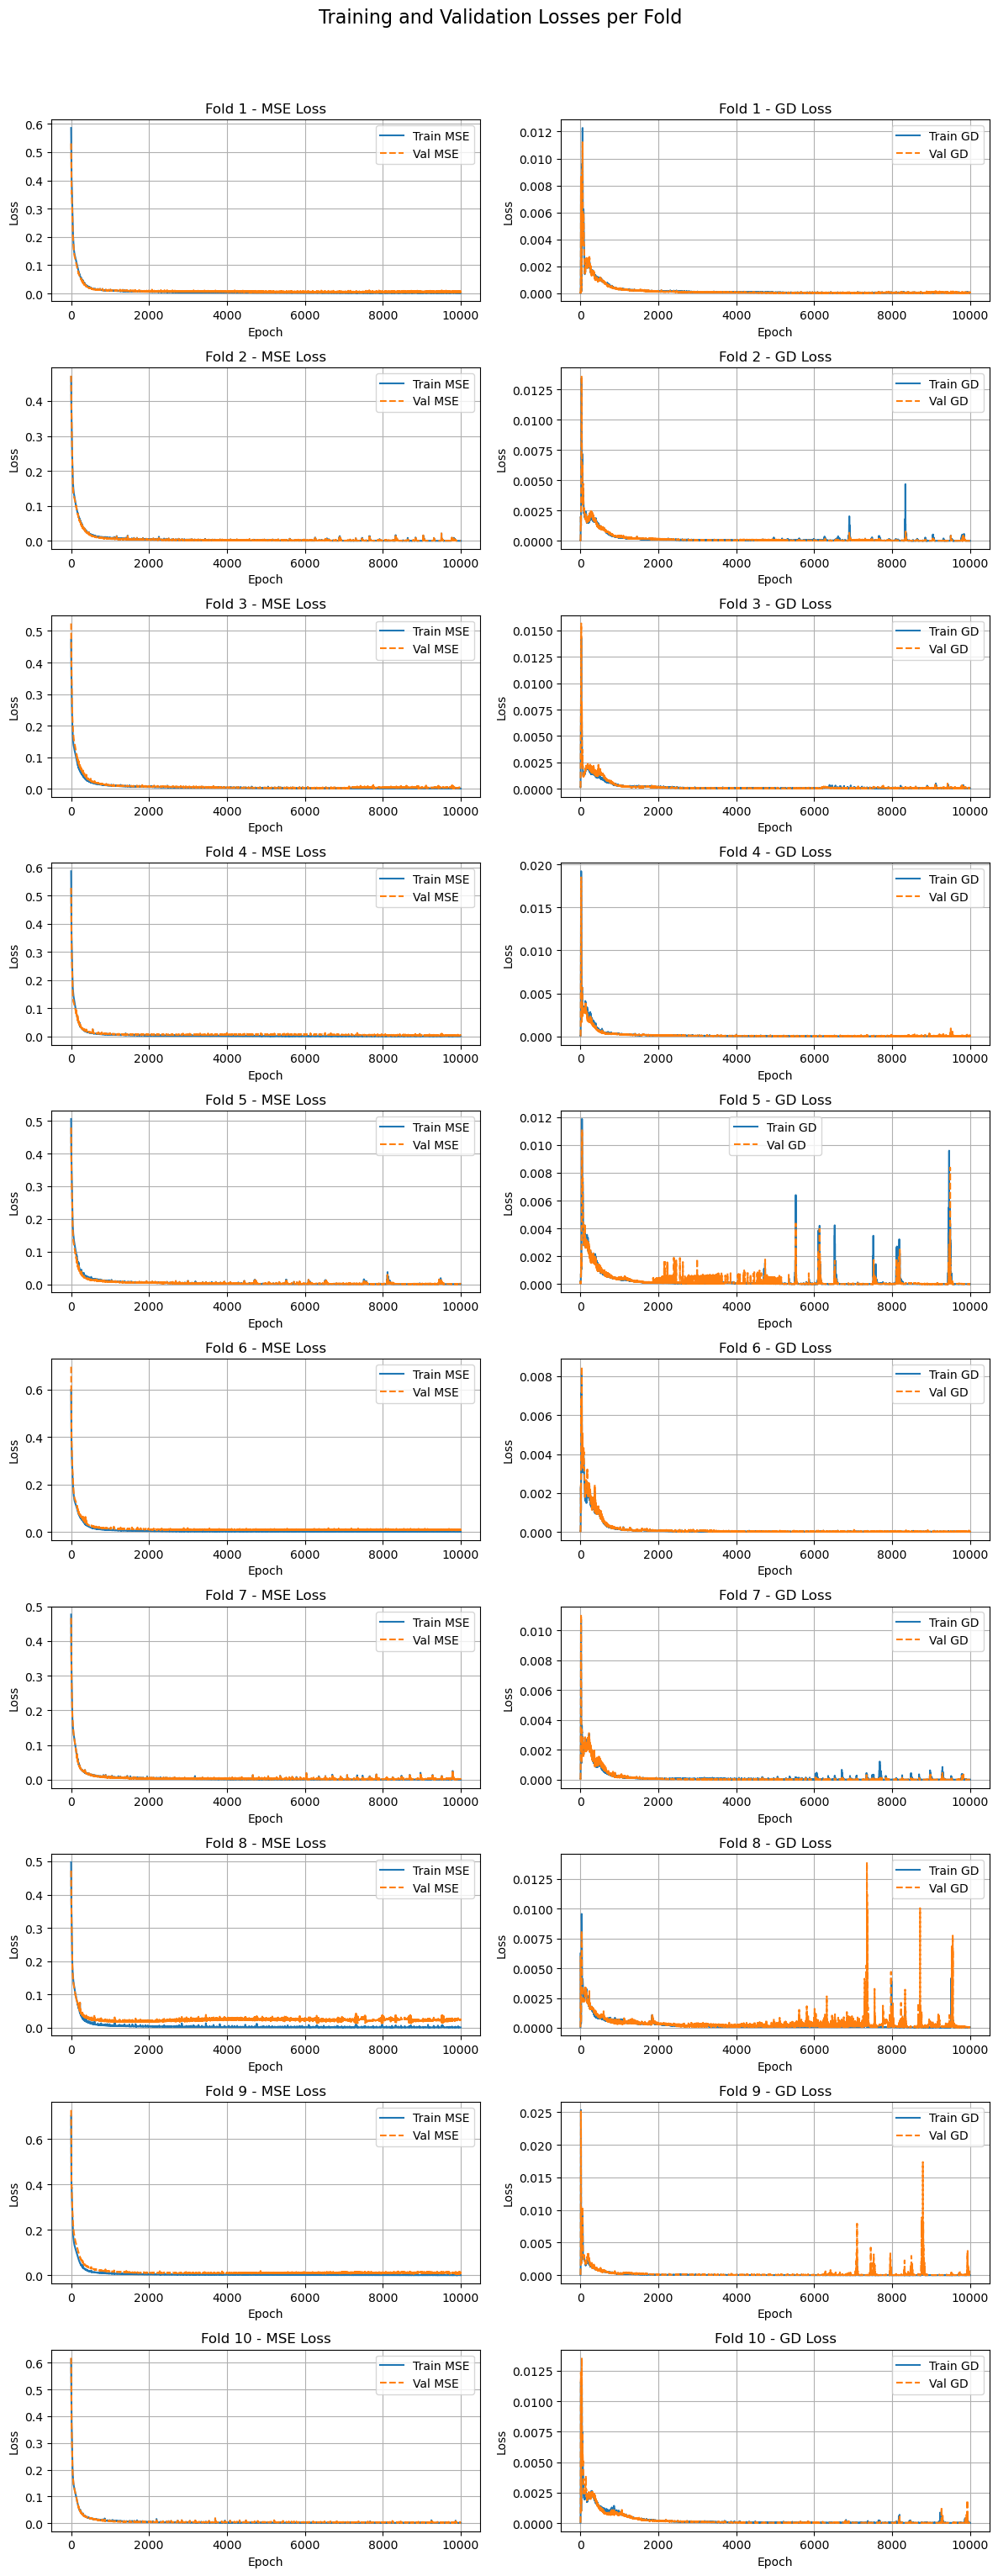

In [ ]:
epochs = range(1, num_epochs + 1)

print(train_mse_per_fold)

fig, axes = plt.subplots(nrows=k_folds, ncols=2, figsize=(12, 3 * k_folds))
fig.suptitle("Training and Validation Losses per Fold", fontsize=16, y=1.02)

for fold in range(k_folds):
    # MSE plot
    ax_mse = axes[fold, 0]
    ax_mse.plot(epochs, train_mse_per_fold[fold], label="Train MSE", linestyle="-")
    ax_mse.plot(epochs, val_mse_per_fold[fold], label="Val MSE", linestyle="--")
    ax_mse.set_title(f"Fold {fold + 1} - MSE Loss")
    ax_mse.set_xlabel("Epoch")
    ax_mse.set_ylabel("Loss")
    ax_mse.legend()
    ax_mse.grid(True)

    # GD plot
    ax_gd = axes[fold, 1]
    ax_gd.plot(epochs, train_gd_per_fold[fold], label="Train GD", linestyle="-")
    ax_gd.plot(epochs, val_gd_per_fold[fold], label="Val GD", linestyle="--")
    ax_gd.set_title(f"Fold {fold + 1} - GD Loss")
    ax_gd.set_xlabel("Epoch")
    ax_gd.set_ylabel("Loss")
    ax_gd.legend()
    ax_gd.grid(True)

plt.tight_layout()
plt.show()

### PINN evaluation

Evaluating the model with the selected hyperparameters

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    features, labels, test_size=0.2, random_state=42
)

# Scale features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert to tensors and move to device
X_train_tensor = torch.tensor(
    X_train_scaled, dtype=torch.float32, requires_grad=True
).to(device)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32, requires_grad=True).to(
    device
)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32, requires_grad=True).to(
    device
)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(device)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(device)

# Model and optimizer
input_size = X_train.shape[1]
output_size = 2
model = NeuralNetArchitecture(input_size, output_size).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Training loop
for epoch in range(num_epochs):
    model.train()

    # Forward pass
    outputs = model(X_train_tensor)

    # Loss
    combined_loss = gibbs_duhem_loss(outputs, y_train_tensor, X_train_tensor, lambda_gd)
    loss = combined_loss[0]

    # Validation loss
    val_outputs = model(X_val_tensor)
    val_combined_loss = gibbs_duhem_loss(
        val_outputs, y_val_tensor, X_val_tensor, lambda_gd
    )
    val_loss = val_combined_loss[0]

    # Backward propagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch + 1}: Training loss -> {loss}")
        print(f"Epoch {epoch + 1}: Validation loss -> {val_loss}")

# Save final model
MODEL_PATH = Path("./models")
torch.save(model.state_dict(), MODEL_PATH / f"trained_pinn.pt")

# Evaluate test data
test_outputs = model(X_test_tensor)
test_combined_loss = gibbs_duhem_loss(
    test_outputs, y_test_tensor, X_test_tensor, lambda_gd
)
test_loss = test_combined_loss[0]
test_residuals = test_combined_loss[3]

# Print loss for final model
print(f"Training loss: {loss.item(): .4f}")
print(f"Validation loss: {val_loss.item(): .4f}")
print(f"Testing loss: {test_loss.item(): .4f}")

Epoch 20: Training loss -> 0.3477160930633545
Epoch 20: Validation loss -> 0.3150738477706909
Epoch 40: Training loss -> 0.20835478603839874
Epoch 40: Validation loss -> 0.18766285479068756
Epoch 60: Training loss -> 0.1636577695608139
Epoch 60: Validation loss -> 0.1503324806690216
Epoch 80: Training loss -> 0.14188896119594574
Epoch 80: Validation loss -> 0.12928767502307892
Epoch 100: Training loss -> 0.12925004959106445
Epoch 100: Validation loss -> 0.11752093583345413
Epoch 120: Training loss -> 0.11849715560674667
Epoch 120: Validation loss -> 0.1089642196893692
Epoch 140: Training loss -> 0.10795040428638458
Epoch 140: Validation loss -> 0.10060551762580872
Epoch 160: Training loss -> 0.09507393836975098
Epoch 160: Validation loss -> 0.08959324657917023
Epoch 180: Training loss -> 0.08087684214115143
Epoch 180: Validation loss -> 0.07642265409231186
Epoch 200: Training loss -> 0.06764593720436096
Epoch 200: Validation loss -> 0.06398272514343262
Epoch 220: Training loss -> 0.057

Plotting Predicted vs Experimental Values for $\gamma_1$

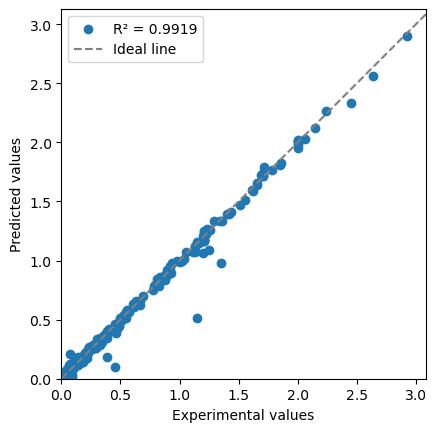

In [43]:
# Calculate R²
r2_metric = R2Score()
r2 = r2_metric(test_outputs[:, 0], y_test_tensor[:, 0]).item()

# Convert tensors to CPU and NumPy for plotting
y_test_np = y_test_tensor[:, 0].cpu().numpy()
preds_np = test_outputs[:, 0].detach().cpu().numpy()

# Plot the scatter plot
plt.scatter(y_test_np, preds_np, label=f"R² = {r2:.4f}")
plt.xlabel("Experimental values")
plt.ylabel("Predicted values")
plt.axis("equal")
plt.axis("square")
plt.xlim([0, plt.xlim()[1]])
plt.ylim([0, plt.ylim()[1]])

# Plot ideal line - Predicted value equal to Experimental
max_val = max(plt.xlim()[1], plt.ylim()[1])
plt.plot(
    [0, max_val],
    [0, max_val],
    linestyle="--",
    color="gray",
    label="Ideal line",
)

plt.legend(loc="upper left")
plt.show()

Plotting Predicted vs Experimental Values for $\gamma_2$

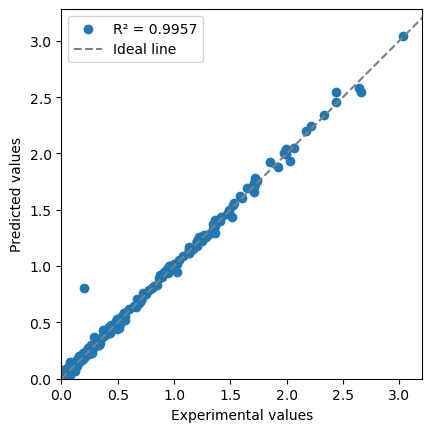

In [44]:
# Calculate R²
r2_metric = R2Score()
r2 = r2_metric(test_outputs[:, 1], y_test_tensor[:, 1]).item()

# Convert tensors to CPU and NumPy for plotting
y_test_np = y_test_tensor[:, 1].cpu().numpy()
preds_np = test_outputs[:, 1].detach().cpu().numpy()

# Plot the scatter plot
plt.scatter(y_test_np, preds_np, label=f"R² = {r2:.4f}")
plt.xlabel("Experimental values")
plt.ylabel("Predicted values")
plt.axis("equal")
plt.axis("square")
plt.xlim([0, plt.xlim()[1]])
plt.ylim([0, plt.ylim()[1]])

# Plot ideal line - Predicted value equal to Experimental
max_val = max(plt.xlim()[1], plt.ylim()[1])
plt.plot(
    [0, max_val],
    [0, max_val],
    linestyle="--",
    color="gray",
    label="Ideal line",
)

plt.legend(loc="upper left")
plt.show()

Plotting Gibbs-Duhem Residual Values

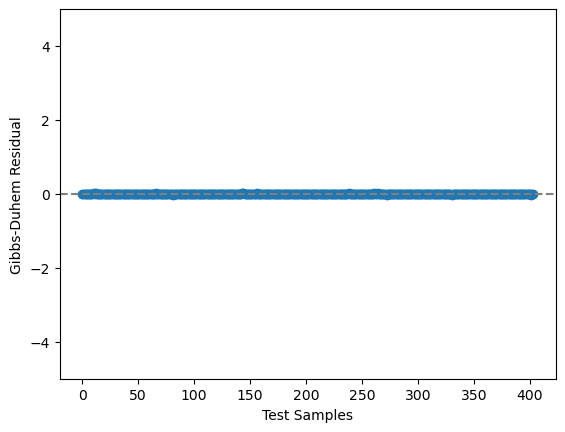

In [ ]:
# Convert tensor to NumPy
np_gd_residuals = test_residuals.detach().cpu().numpy()

# Create index for each test sample
test_idxs = np.arange(len(np_gd_residuals))

# Plot residuals against observation index
plt.scatter(test_idxs, np_gd_residuals)
plt.axhline(0, color="gray", linestyle="--")
plt.ylim(-5, 5)
plt.xlabel("Test Samples")
plt.ylabel("Gibbs-Duhem Residual")
plt.show()